In [21]:
import os

os.path.exists("/Users/toiizumitarou/day3/day2/sample_day2.csv")

False

In [1]:
import os

os.path.exists("/Users/toiizumitarou/day2/sample_day2.csv")

True

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/toiizumitarou/day2/sample_day2.csv")
df.head()
df.dtypes

patient_id    object
age           object
value         object
date          object
flag          object
dtype: object

In [7]:
# 数値にすべきカラムを numeric に変換
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["value"] = pd.to_numeric(df["value"], errors="coerce")
df["flag"] = pd.to_numeric(df["flag"], errors="coerce")

# 日付を datetime 型に変換
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# 型が変わったか確認
df.dtypes

/var/folders/by/yd89_rh944vfysllq_zmnfyw0000gn/T/ipykernel_25561/2574723158.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["date"], errors="coerce")


patient_id            object
age                  float64
value                float64
date          datetime64[ns]
flag                 float64
dtype: object

In [9]:
#欠損値チェック
df.isnull().sum()

patient_id    0
age           1
value         1
date          1
flag          1
dtype: int64

In [11]:
# value の欠損は平均で埋める（とりあえずの実務的処置）
df["value"] = df["value"].fillna(df["value"].mean())

# age / flag / date に欠損があれば、今回は「行ごと削除」でいい
df = df.dropna(subset=["age", "flag", "date"])

df.isnull().sum()

patient_id    0
age           0
value         0
date          0
flag          0
dtype: int64

In [13]:
#年齢をグループ化（"young", "middle", "senior"）
df["age_group"] = pd.cut(
    df["age"],
    bins=[0,40,60,120],
    labels=["young", "middle", "senior"]
)

In [15]:
#value から high_risk フラグを作る
df["high_risk"] = (df["value"] > 7.5).astype(int)

In [17]:
# 年齢層ごとの平均値
df.groupby("age_group")["value"].mean()

# high_risk の件数
df["high_risk"].value_counts()

# flag × high_risk のクロス集計
df.groupby(["flag", "high_risk"]).size()

/var/folders/by/yd89_rh944vfysllq_zmnfyw0000gn/T/ipykernel_25561/1367754332.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_group")["value"].mean()


flag  high_risk
0.0   0            50
1.0   0            24
      1            26
dtype: int64

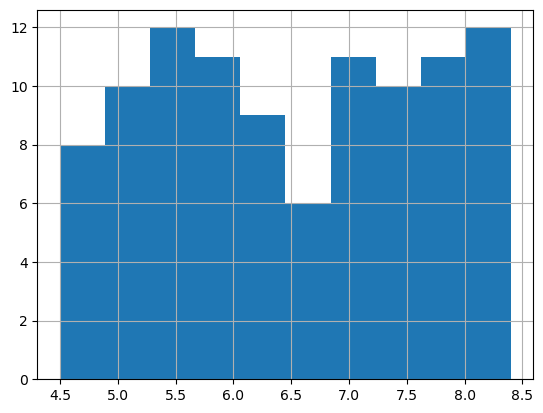

/var/folders/by/yd89_rh944vfysllq_zmnfyw0000gn/T/ipykernel_25561/492592867.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_group")["value"].mean().plot(kind="bar")


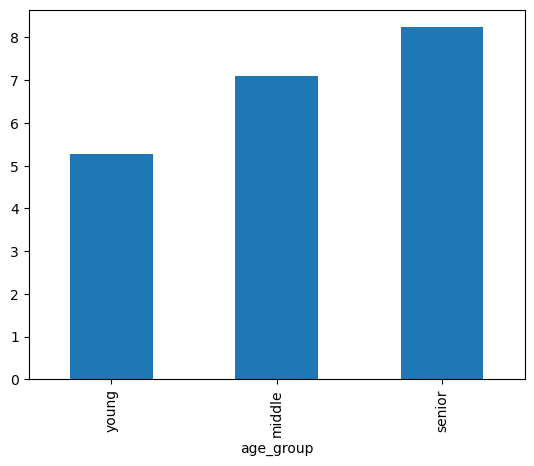

In [19]:
import matplotlib.pyplot as plt

# 1. 検査値分布のヒストグラム
df["value"].hist()
plt.show()

# 2. 年齢層ごとの平均値（バー）
df.groupby("age_group")["value"].mean().plot(kind="bar")
plt.show()